## COMP 6934 Winter 2026 In class Work 14

Methodology per Tamara Munzner.


### Problem Set 14

Apply the *what* and *why* portions of Munzner's approach.

We'll be using the [taxis.csv](datasets/tavis.csv) data set for this problem set. It is included in the [seaborn sample data](https://github.com/mwaskom/seaborn-data) and originates from the [NYC taxi comission](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).

Note that there are multiple published analyses and notebooks on kaggle (e.g. https://www.kaggle.com/code/mariapushkareva/medical-insurance-cost-with-linear-regression/notebook) covering this dataset. You can look on kaggle if you need more information on the semantics and structure of this data.

#### Problem 14.1 - What -

Perform a - *what* - analysis on the dataset. This include determining the Data and Dataset Types, and the Attribute types for each attribute, and any other relevant charateristics from Munzner's  *what* methodology. 

**Step 1: Load and Inspect the Data**

In [89]:
import pandas as pd

In [90]:
df = pd.read_csv("taxis.csv")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pickup           6433 non-null   str    
 1   dropoff          6433 non-null   str    
 2   passengers       6433 non-null   int64  
 3   distance         6433 non-null   float64
 4   fare             6433 non-null   float64
 5   tip              6433 non-null   float64
 6   tolls            6433 non-null   float64
 7   total            6433 non-null   float64
 8   color            6433 non-null   str    
 9   payment          6389 non-null   str    
 10  pickup_zone      6407 non-null   str    
 11  dropoff_zone     6388 non-null   str    
 12  pickup_borough   6407 non-null   str    
 13  dropoff_borough  6388 non-null   str    
dtypes: float64(5), int64(1), str(8)
memory usage: 703.7 KB


In [92]:
df.describe()

,passengers,distance,fare,tip,tolls,total
count,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
std,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570
min,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000


In [93]:
df.shape

(6433, 14)

This tells you:
- How many rows/columns
- Column names and types (Python's inferred types)
- Missing values
- Basic statistics

**Step 2: Map to Munzner's Data Types**

Munzner identifies four **dataset types**:

| Dataset Type | Definition | Example |
|---|---|---|
| **Table** | Records (rows) with attributes (columns) | Your taxi.csv is almost certainly this |
| **Network** | Entities + pairwise relationships | Only if you have explicit edges (e.g., route A → route B) |
| **Tree** | Hierarchical data | Only if rows have parent-child relationships |
| **Field** | Continuous spatial data with values | Only if you have lat/lon + measurements on a continuum |

**Your likely answer**: Table (unless taxi data includes spatial fields or networks)

**Step 3: Classify Each Attribute**

For *each column*, determine the **attribute type**:

| Attribute Type | Definition | Examples |
|---|---|---|
| **Categorical (Nominal)** | Unordered categories; no ranking | taxi_color, driver_id, pickup_zone |
| **Categorical (Ordinal)** | Ordered categories; ranking matters | service_level (economy < premium), rating (1-5 stars) |
| **Quantitative (Interval)** | Numeric; differences meaningful, no true zero | temperature, time of day (0-24h wraps) |
| **Quantitative (Ratio)** | Numeric; true zero, ratios meaningful | fare, distance, duration, number_of_passengers |

**Your approach for each column**:
1. Look at the values: Are they numbers or text?
2. Ask: Do order/ranking matter? 
3. Ask: Does a ratio make sense? (Is "double the value" meaningful?)

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pickup           6433 non-null   str    
 1   dropoff          6433 non-null   str    
 2   passengers       6433 non-null   int64  
 3   distance         6433 non-null   float64
 4   fare             6433 non-null   float64
 5   tip              6433 non-null   float64
 6   tolls            6433 non-null   float64
 7   total            6433 non-null   float64
 8   color            6433 non-null   str    
 9   payment          6389 non-null   str    
 10  pickup_zone      6407 non-null   str    
 11  dropoff_zone     6388 non-null   str    
 12  pickup_borough   6407 non-null   str    
 13  dropoff_borough  6388 non-null   str    
dtypes: float64(5), int64(1), str(8)
memory usage: 703.7 KB


**Step 4: Determine Other Characteristics**

Beyond type, note:

- **Cardinality**: How many distinct values? (High cardinality categorical = problem for some vis)
- **Range/Domain**: Min, max, distribution
- **Missingness**: Null counts per column
- **Granularity**: What does each row represent? (individual trip, daily aggregate, driver-level stats?)
- **Temporal**: Any time-based columns? (datetime type, frequency, span)
- **Spatial**: Any geographic attributes? (lat/lon, zip codes, zones)

**Step 5: Write It Up**

Structure your answer:
```
DATASET TYPE: Table
- Dimensionality: N rows × M columns
- Granularity: Each row represents [one taxi trip / one driver shift / ...]

ATTRIBUTES:

1. pickup_time
   - Type: Quantitative (Interval)
   - Cardinality: High (continuous time)
   - Range: [start_date to end_date]
   - Temporal: Yes

2. fare_amount
   - Type: Quantitative (Ratio)
   - Cardinality: High
   - Range: [$X to $Y]
   - Notes: Has outliers / missing values

3. pickup_zone
   - Type: Categorical (Nominal)
   - Cardinality: ~50 distinct zones
   - Notes: Spatial information embedded

... [repeat for all columns]

#### Problem 14.2 - Why -

To produce { action, target } pairs under Munzner's *why* methodology, you need some questions or objectives in mind; you also need a basic understanding of what the data values mean (semantics).  

Produce action/target pairs appropriate to each of the following questions/goals:
* What factors affect or influence tipping?
* Does one part of new york produce higher tips?
* Show that distance travelled affects tips.

Make clear which action/target pairs go with each question/goal.

In [95]:
df.tail()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn
6432,2019-03-13 19:31:22,2019-03-13 19:48:02,1,3.85,15.0,3.36,0.0,20.16,green,credit card,Boerum Hill,Windsor Terrace,Brooklyn,Brooklyn


In [96]:
df.shape

(6433, 14)

In [97]:
sum(df.tip > 0)/6433

0.640758588527903

In short:

* Action = what cognitive operation you perform
* Target = what aspect of the data you're operating on

Common actions: *Discover, Explore, Identify, Compare, Correlate, Rank, Summarize, Anomaly Detection*

**Question 1: "What factors affect or influence tipping?"**

**Goal:** Understand which variables have explanatory power over tip behavior.

**Action/Target Pairs**:

| # | Action | Target | Reasoning |
|---|--------|--------|-----------|
| 1.1 | **Correlate** | {distance, tip} | Quantitative association: does longer rides → higher tips? |
| 1.2 | **Correlate** | {fare, tip} | Quantitative association: does higher fare → higher tips? |
| 1.3 | **Correlate** | {passengers, tip} | Quantitative association: group size effect on tipping? |
| 1.4 | **Compare** | {payment method} vs {tip amount} | Categorical split: do credit card users tip differently than cash? |
| 1.5 | **Compare** | {time of day} vs {tip amount} | Temporal pattern: do rush hours, nights, weekends affect tipping? |
| 1.6 | **Identify** | {zero vs non-zero tips} by {payment type} | Categorical anomaly: which groups have high non-tipping rates? |
| 1.7 | **Summarize** | {tip as % of fare} across {all factors} | Derive new attribute (tip ratio) and test its relationships |

**Most direct pairs for "factors"**: 1.1, 1.2, 1.3, 1.4

**Question 2: "Does one part of New York produce higher tips?"**

**Goal**: Geographic/spatial comparison of tip behavior.

**Action/Target Pairs**:

| # | Action | Target | Reasoning |
|---|--------|--------|-----------|
| 2.1 | **Compare** | {pickup_borough} vs {mean tip} | Aggregate: which borough has highest average tips? |
| 2.2 | **Compare** | {pickup_zone} vs {mean tip} | Finer granularity: which specific zone leads? |
| 2.3 | **Rank** | {pickup_borough or pickup_zone} by {tip amount} | Order geographic regions by tipping magnitude |
| 2.4 | **Identify** | {high-tip zones} and {low-tip zones} | Categorical segmentation: which areas are outliers? |
| 2.5 | **Compare** | {pickup_borough} vs {dropoff_borough} | Directional analysis: do intra-borough vs cross-borough trips differ? |

**Most direct pairs for "which part"**: 2.1, 2.2, 2.3

**Question 3: "Show that distance travelled affects tips.**

**Goal**: Demonstrate causal/correlational relationship; persuasive evidence.

**Action/Target Pairs**:

| # | Action | Target | Reasoning |
|---|--------|--------|-----------|
| 3.1 | **Correlate** | {distance, tip} | Quantitative association with strength (correlation coeff) |
| 3.2 | **Compare** | {distance quartiles} vs {median tip per quartile} | Binned comparison: does tip increase monotonically with distance? |
| 3.3 | **Derive & Correlate** | {distance, tip ratio (tip/fare)} | Control for confound: is it distance or fare? |
| 3.4 | **Identify** | {outliers and trend} in {distance-tip scatter} | Visual regression: show linear fit + residuals to make relationship clear |
| 3.5 | **Summarize** | {distance ranges} and {corresponding tip distributions} | Aggregate: mean, median, quartiles for each distance band |

**Most direct pairs for "distance affects tips"**: 3.1, 3.2, 3.4

#### Problem 14.3 - How - (but not How)

We haven't covered Munzner's *How* methods, so we are going to try to complete the design without her guidance in this step.

Pick three of the action/target pairs identified in 14.2, and create a plot (in seaborn, plotly, etc.) that you think corresponds to that action/target pair. (3 plots total)

Make it clear which action/target pair goes with each plot 

In [98]:
import plotly.express as px

Plot 1: Scatter + Trendline

Action: CORRELATE
* Target: {distance, tip}
* Question: 1.1 - What factors affect tipping?
* Interpretation: Shows the co-variation between distance and tip with a    fitted regression line. Pearson r = 0.143 (weak positive correlation—longer trips have slightly higher tips, but with substantial scatter).

In [99]:
corr_coefficient = df['distance'].corr(df['tip'])
print(f"Pearson correlation (distance, tip): {corr_coefficient:.3f}")

Pearson correlation (distance, tip): 0.453


In [126]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [127]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='str')

In [128]:
df.payment.value_counts()

payment
credit card    4577
cash           1812
Name: count, dtype: int64

In [129]:
df.groupby('payment')['tip'].agg(['mean', 'std']).reset_index()

,payment,mean,std
0,cash,0.000000,0.000000
1,credit card,2.781805,2.488783


In [130]:
df[df.payment == "cash"][["tip", "payment"]].head(100)

,tip,payment
1,0.0,cash
10,0.0,cash
13,0.0,cash
14,0.0,cash
15,0.0,cash
...,...,...
300,0.0,cash
301,0.0,cash
302,0.0,cash
304,0.0,cash


In [131]:
def plot_compare_payment_vs_tip(df, ax):
    """
    PLOT 1: COMPARE {payment_method} vs {tip}

    Action: COMPARE
    Target: payment (categorical) vs. tip (quantitative)
    Visualization: Bar chart with error bars
    """
    payment_tips = df.groupby('payment')['tip'].agg(
        ['mean', 'std']).reset_index()

    sns.barplot(
        data=payment_tips,
        x='payment',
        y='mean',
        ax=ax,
        hue='payment',
        palette='Set2',
        errorbar='sd',
        legend=False
    )

    ax.set_title(
        'PLOT 1: COMPARE {payment} vs {mean tip}\n'
        'Action: Compare | Target: payment_method, tip_amount',
        fontsize=11,
        fontweight='bold'
    )
    ax.set_xlabel('Payment Method', fontsize=10)
    ax.set_ylabel('Mean Tip ($)', fontsize=10)
    ax.set_ylim(0, max(payment_tips['mean']) * 1.3)

    # Add value labels on bars
    for i, (idx, row) in enumerate(payment_tips.iterrows()):
        ax.text(i, row['mean'] + 0.15, f"${row['mean']:.2f}",
                ha='center', fontsize=9, fontweight='bold')

    return ax

In [ ]:
def plot_correlate_distance_vs_tip(df, ax):
    """
    PLOT 2: CORRELATE {distance, tip}

    Action: CORRELATE
    Target: distance (quantitative) × tip (quantitative)
    Visualization: Scatter plot + trend line
    """
    sns.scatterplot(
        data=df,
        x='distance',
        y='tip',
        ax=ax,
        alpha=0.5,
        s=40,
        color='steelblue'
    )

    # Add polynomial trend line
    z = np.polyfit(df['distance'], df['tip'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df['distance'].min(), df['distance'].max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=2.5,
            label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')

    # Calculate correlation coefficient
    corr = df['distance'].corr(df['tip'])

    ax.set_title(
        f'PLOT 2: CORRELATE {{distance, tip}}\n'
        f'Action: Correlate | Target: distance, tip\n'
        f'Pearson r = {corr:.3f}',
        fontsize=11,
        fontweight='bold'
    )
    ax.set_xlabel('Distance (miles)', fontsize=10)
    ax.set_ylabel('Tip ($)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    return ax

In [ ]:
def plot_compare_rank_borough_vs_tip(df, ax):
    """
    PLOT 3: COMPARE & RANK {pickup_borough} vs {median tip}

    Action: COMPARE (with RANK ordering)
    Target: borough (categorical) vs. tip (quantitative)
    Visualization: Sorted bar chart
    """
    borough_tips = df.groupby('pickup_borough')['tip'].median().sort_values(
        ascending=False
    ).reset_index()

    sns.barplot(
        data=borough_tips,
        x='pickup_borough',
        y='tip',
        ax=ax,
        hue='pickup_borough',
        palette='muted',
        legend=False
    )

    ax.set_title(
        'PLOT 3: COMPARE & RANK {pickup_borough} by {median tip}\n'
        'Action: Compare/Rank | Target: borough, tip_amount',
        fontsize=11,
        fontweight='bold'
    )
    ax.set_xlabel('Borough', fontsize=10)
    ax.set_ylabel('Median Tip ($)', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for i, (idx, row) in enumerate(borough_tips.iterrows()):
        ax.text(i, row['tip'] + 0.05, f"${row['tip']:.2f}",
                ha='center', fontsize=9, fontweight='bold')

    return ax

<Axes: title={'center': 'PLOT 3: COMPARE & RANK {pickup_borough} by {median tip}\nAction: Compare/Rank | Target: borough, tip_amount'}, xlabel='Borough', ylabel='Median Tip ($)'>

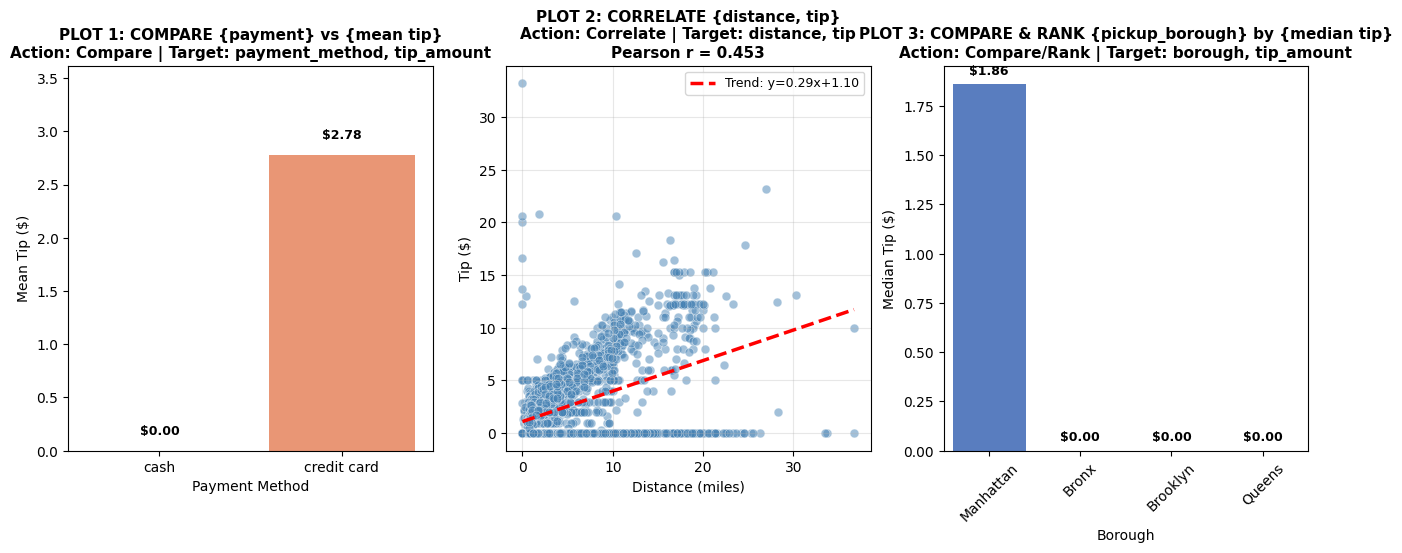

In [134]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_compare_payment_vs_tip(df, axes[0])
plot_correlate_distance_vs_tip(df, axes[1])
plot_compare_rank_borough_vs_tip(df, axes[2])

In [137]:
df["payment"].value_counts().reset_index()

,payment,count
0,credit card,4577
1,cash,1812


# Attributions

Be sure to add your own sources or indicate you have none to add.  Sources can be web sites, text materials, and so on. They do not have to be hyperlinks. Other people are also sources, but they are not allowed for in class credit problems.

| Source | What is it | How used |
|--|--|--|
| https://github.com/mwaskom/seaborn-data Seaborn data samples | data sets | taken directly as csv files  |
| T. Munzner book https://www.cs.ubc.ca/~tmm/vadbook/| methodology for analysis and design | design choice methods |